### Install packages

In [1]:
%pip install -q networkx pandas matplotlib python-louvain pyvis affiliation-builder  # Install quietly

Note: you may need to restart the kernel to use updated packages.


### Import dependencies

In [2]:
# Core libraries
import json
import logging
from pathlib import Path

# Network analysis
import networkx as nx
from networkx.algorithms import bipartite
from community import community_louvain

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# affiliation-builder
from affiliation_builder import build

### Configure logging

In [3]:
logging.getLogger('affiliation_builder').setLevel(logging.INFO)  # Display console feedback
logging.getLogger('affiliation_builder').addHandler(logging.StreamHandler())

### Load JSON and build bipartite network

In [4]:
G_bipartite = build(
    json_path="../examples/amp-events.json",
    node_set_0_key="listEvent",
    node_set_1_keys=["listPerson", "org"],
    identifier_key="xml:id",
    node_set_1_identifier_key="sameAs"
)

Affiliation network builder started
JSON source: ../examples/amp-events.json
Node-set-0 key: 'listEvent'
Node-set-1 keys: ['listPerson', 'org']
Identifier key: 'xml:id'
Node-set-1 identifier key: 'sameAs'
Local file path detected: ../examples/amp-events.json
Local JSON file successfully loaded
Wrapped object format with 105 items in 'listEvent' detected
NetworkX graph initialized
Bipartite network construction complete
Total edges (affiliations): 245
Total nodes: 188
Node set 0 (listEvent): 105 nodes
Node set 1 (['listPerson', 'org']): 83 nodes
✓ Graph structure is valid bipartite


### Extract node sets

In [5]:
events = {n for n, d in G_bipartite.nodes(data=True) if d['bipartite'] == 0}  # Create set of node IDs in node-set 0
participants = {n for n, d in G_bipartite.nodes(data=True) if d['bipartite'] == 1}

### Filter bipartite graph

#### Define filter

In [6]:
# Filter by event date

def filter_by_date(G_bipartite, start_date, end_date):
    """
    Filter bipartite graph to events within a date range.
    Uses notBefore-iso attribute for filtering.
    
    Parameters
    ----------
    G_bipartite : networkx.Graph
        Bipartite event-participant graph
    start_date : str
        Start date in ISO format (e.g., '1960-01-01')
    end_date : str
        End date in ISO format (e.g., '1970-12-31')
    
    Returns
    -------
    networkx.Graph
        Filtered bipartite graph
    """
    filtered_events = []  # List to collect relevant event node IDs

    for node, data in G_bipartite.nodes(data=True):  # Loop through all nodes with their IDs and attributes
        if data.get('bipartite') == 0:  # Get events
            event_date = data.get('notBefore-iso', '')[:10]  # Get event start date attribute
            if event_date and start_date <= event_date <= end_date:  # Check event start date is in range
                filtered_events.append(node)  # Add event node ID
    
    filtered_participants = set()  # Set to collect relevant participant node IDs

    for event in filtered_events:
        filtered_participants.update(G_bipartite.neighbors(event))  # Add participant node IDs
    
    filtered_nodes = set(filtered_events) | filtered_participants  # Combine relevant events and participants in single set
    
    return G_bipartite.subgraph(filtered_nodes).copy()  # Return independent filtered graph


#### Apply filters

In [7]:
G_filtered_date = filter_by_date(G_bipartite, '1957-01-01', '1973-09-29')  # Filter by event date

# Update node sets
events = {n for n, d in G_filtered_date.nodes(data=True) if d['bipartite'] == 0}
participants = {n for n, d in G_filtered_date.nodes(data=True) if d['bipartite'] == 1}

### Unipartite projection

In [8]:
G = bipartite.weighted_projected_graph(G_filtered_date, participants)  # Create participant network with weighted edges

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)  # From node-node-attributes tuples, create list of edges sorted by weight, highest first
for u, v, d in edges_by_weight[:5]:  # Unpack
    print(f"  {u} — {v}: {d['weight']} shared events")

Nodes: 62
Edges: 164

Strongest connections:
  amp_person_2 — amp_person_1: 34 shared events
  amp_person_1 — amp_person_4: 11 shared events
  amp_person_2 — amp_person_4: 7 shared events
  amp_person_1 — amp_organization_9: 3 shared events
  amp_person_109 — amp_person_1: 2 shared events


### Extract ego network

In [9]:
ego = 'amp_person_1'  # Define ego

G_ego = nx.ego_graph(G, ego)  # Extract network with ego and directly connected alters, including alter-alter edges

print(f"Alters: {G_ego.number_of_nodes() - 1}")  # Subtract ego
print(f"Edges: {G_ego.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G_ego.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_by_weight[:5]:
    print(f"  {u} — {v}: {d['weight']} shared events")

Alters: 45
Edges: 129

Strongest connections:
  amp_person_2 — amp_person_1: 34 shared events
  amp_person_1 — amp_person_4: 11 shared events
  amp_person_2 — amp_person_4: 7 shared events
  amp_person_1 — amp_organization_9: 3 shared events
  amp_person_109 — amp_person_1: 2 shared events


### Compute ego network metrics

#### Create alter network

In [10]:
# Create stand-alone alters network
G_alters = G_ego.copy()
G_alters.remove_node(ego)

print(f"Alters: {G_alters.number_of_nodes()}")
print(f"Edges: {G_alters.number_of_edges()}")

Alters: 45
Edges: 84


#### Explore ego network

In [11]:
# Get list of weights from node-node-edge triples
weights = [d['weight'] for _, _, d in G_ego.edges(data=True)]

# Wrap list as pandas Series; create new Series of unique weight values and their counts (sorted by weight values)
pd.Series(weights).value_counts().sort_index()

1     119
2       6
3       1
7       1
11      1
34      1
Name: count, dtype: int64

#### Explore alter network

In [12]:
weights = [d['weight'] for _, _, d in G_alters.edges(data=True)]

pd.Series(weights).value_counts().sort_index()

1    82
2     1
7     1
Name: count, dtype: int64

#### Analyze alter network

In [ ]:
# Density: proportion of possible edges that exist (actual/possible)
# Low density (close to 0) = ego bridges separate individuals
# High density (close to 1) = tight-knit group
alter_density = nx.density(G_alters)
print(f"Alter network density: {alter_density:.3f}")

# Components: number of separate unconnected groups among alters
# 1 = all alters connected through each other; >1 = ego bridges separate groups
# High number = strong brokerage position of ego
alter_components = nx.number_connected_components(G_alters)
print(f"Components among alters: {alter_components}")

# Clustering: proportion of possible interconnections between each node's neighbors (actual/possible)
# 0 = no triangles (loose chains); 1 = all acquaintances of acquaintances connected
# High clustering = tight-knit components, not just chains of contacts
# if G_alters.number_of_edges() > 0:  # Prevent errors, clustering undefined for isolated nodes
#     alter_clustering = nx.average_clustering(G_alters)
#     print(f"Average clustering among alters: {alter_clustering:.3f}")

# unipartite clustering coefficient removed — artifact of affiliation projection:
# any event with ≥3 participants induces cliques;
# alternatives:
# - two-mode/bipartite clustering (Opsahl 2013; Latapy et al. 2008),
# - projection-plus-correction: weighted clustering (Barrat/Onnela/Fagiolo)
# counting only triangles supported by ≥2 events,
# and/or z-score against a bipartite configuration-model null.

# Weighted degree: sum of edge weights (co-affiliations) for each node
# Higher value = more frequent co-participation with others
# Alters with top weighted degrees are most firmly embedded in ego's social world
weighted_degree_alters = {node: sum(d['weight'] for _, _, d in G_alters.edges(node, data=True)) for node in G_alters.nodes()}  # Create dictionary that maps nodes weighted degrees to their IDs
print("\nTop weighted alters:")
for node, value in sorted(weighted_degree_alters.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {value}")    

Alter network density: 0.085
Components among alters: 12

Top weighted alters:
  amp_person_2: 27
  amp_person_4: 22
  amp_person_137: 11
  amp_person_152: 10
  amp_person_73: 9


#### Clique analysis

In [14]:
# Cliques: complete subgraphs where every node connects to every other
# Reveals tightly-knit cores within larger components
# Larger cliques indicate stronger social cohesion
# cliques = list(nx.find_cliques(G_alters))  # List cliques (i.e., lists of node IDs)
# largest_clique = max(cliques, key=len)  # Get largest clique (i.e., with most node IDs)
# print(f"Number of cliques: {len(cliques)}")
# print(f"Largest clique size: {len(largest_clique)} nodes")
# print(f"Largest clique members: {largest_clique}")

# clique analysis removed:
# 'cliques' form automatically when multiple people attend a single event,
# no genuine social cohesion, not meaningful for affiliation network

### Visualize ego network

#### Prepare visualization data

In [15]:
# Assign component membership
component_map = {}
for i, component in enumerate(nx.connected_components(G_alters)):  # Loop through indexed sets of components
    for node in component:  # Loop through nodes in component
        component_map[node] = i  # Assign set index to node
component_map[ego] = -1  # Assign special value to ego node

# Add weighted degree for ego
weighted_degree_ego = weighted_degree_alters.copy()
weighted_degree_ego[ego] = sum(d['weight'] for _, _, d in G_ego.edges(ego, data=True))

# Normalize weighted degree for visualization
max_wd_alters = max(weighted_degree_alters.values())  # Get highest value for alters
node_sizes = [300 + 700 * min(weighted_degree_ego[node] / max_wd_alters, 1) for node in G_ego.nodes()]  # Scale ratio to 0-700 points; cap at 1; set base size to 300

colors = [component_map[node] for node in G_ego.nodes()]  # List component membership values in order of nodes in graph

edge_weights = [G_ego[u][v]['weight'] for u, v in G_ego.edges()]  # Access dictionary of edge attributes; list edge weights in order of edges in graph
# Normalize edge weight
max_weight = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]

pos = nx.spring_layout(G_ego, weight='weight', seed=42)  # Set layout to spring algorithm based on edge weight; fix random starting positions

#### Draw ego network

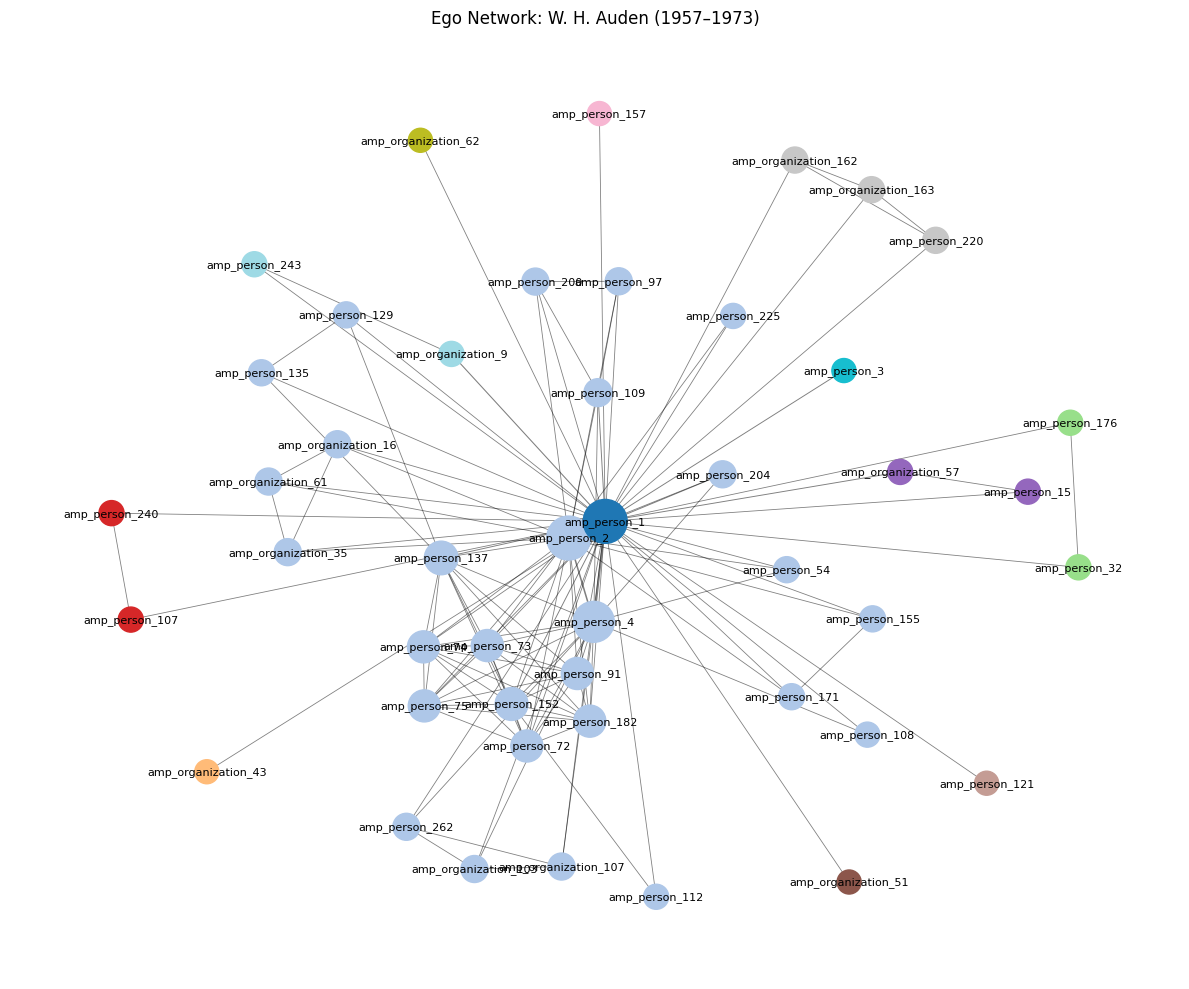

In [16]:
# Plot figure
plt.figure(figsize=(12, 10))  # Set dimensions to 12 by 10 inches
nx.draw_networkx_nodes(G_ego, pos, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)  # Set node layout, sizes, and colors
nx.draw_networkx_edges(G_ego, pos, width=edge_widths, alpha=0.5)  # Set edge layout, widths, and transparency
nx.draw_networkx_labels(G_ego, pos, font_size=8)  # Set label layout and font size
plt.title("Ego Network: W. H. Auden (1957–1973)")
plt.axis('off')  # Hide coordinate axes
plt.tight_layout()  # Adjust margins so that the title and nodes don't get clipped
plt.show()  # Render and display the figure